**Import the useful packages** 

In [1]:
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import os,sys
import pandas as pd

# To avoid problems with tensorflow, add the following lines before importing it
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras

# To avoid problems with nn_functions, add the following lines before importing it 
import sys
sys.path.insert(1, '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt')

#from nn_functions.constants import *
#import nn_functions.diagnostic_functions as diag
#import nn_functions.data_formatting as dfmt
import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *

import define_params 

**Set the filepaths to the input and output data** 

In [2]:
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
fp_all_data = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv'
models = glob.glob(path_model + '*.keras')
histories = glob.glob(path_model + 'history*.csv')

**Set the parameters for this specific run**

In [3]:
mod_size = 'small'
TS_opt = 'extrap'
norm_method = 'std'
exp_name = 'slope_lat_lon'
#exp_name = 'slope_front'
seed_nb = 1
this_collection = 'no_middle_5'
#np.random.seed(seed_nb)
#tf.random.set_seed(seed_nb)

**Look at the model history to see how well it performed**

In [4]:
def load_history(exp_name, this_collection, seed_nb, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
    fp_model = path_model + 'model_nn_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                    + str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.keras'
    fp_history = path_model + 'history_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                    + str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.csv'
    if np.isin(fp_history, histories) == True:
        history = pd.read_csv(fp_history)
        if verbose == 1:
            print('\033[1m' + 'You have requested this model:' + '\033[0m')
            print(fp_model)
    else:
        if verbose == 1:   
            print('\033[1m' + 'The model you have requested does not exist.' + '\033[0m')
            print('\033[1m' + 'These models are currently available:' + '\033[0m')
            for i in range(len(models)):
                print(models[i])    
    return history

In [5]:
seed_nb_array = np.arange(1,11,1)
history_seeds = np.ndarray(len(seed_nb_array), dtype = np.ndarray)
history_seeds2 = np.ndarray(len(seed_nb_array), dtype = np.ndarray)
for i in seed_nb_array:
    history_seeds[i-1] = load_history('slope_lat_lon', 'no_middle_5', seed_nb = i, verbose = 0)
    history_seeds2[i-1] = load_history('slope_front', 'no_middle_5', seed_nb = i, verbose = 0)

In [6]:
def calculate_mean_std(history_seeds):
    cols = list(history_seeds[1])
    column_names = []
    for i in range(len(cols)):
        name_mean = cols[i] + '_mean'
        name_std = cols[i] + '_std'
        column_names.append(name_mean)
        column_names.append(name_std)
    df = pd.DataFrame(columns = column_names)
    for i in range(len(cols)):
        name_mean = cols[i] + '_mean'
        name_std = cols[i] + '_std'
        df[name_mean] = (pd.concat(history_seeds, axis  = 1)[cols[i]]).mean(axis = 1)
        df[name_std] = (pd.concat(history_seeds, axis  = 1)[cols[i]]).std(axis = 1)
    return df

In [7]:
df_lat_lon = calculate_mean_std(history_seeds)
df_front = calculate_mean_std(history_seeds2)


In [8]:
requested_param = 'loss' # 'loss', 'mae', 'mse'
if requested_param == 'mae':
    rp_label = 'Mean absolute error'
elif requested_param == 'loss':
    rp_label = 'Loss'
elif requested_param == 'mse':
    rp_label = 'Mean squared error'

In [9]:
rp_val = 'val_' + requested_param
rp_mean = requested_param + '_mean'
rp_std = requested_param + '_std'
rp_val_mean = 'val_' + requested_param + '_mean'
rp_val_std = 'val_' + requested_param + '_std'

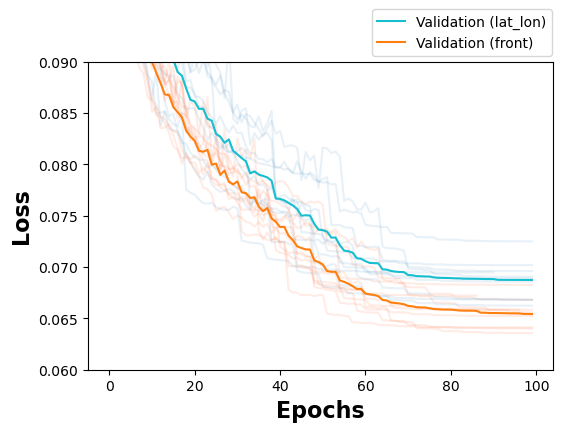

In [10]:
fig, ax = plt.subplots(1,1, figsize = (6,4))
for i in range(10):
    #ax.plot(history_seeds[i][requested_param], color = 'C9', alpha = 0.1)
    ax.plot(history_seeds[i][rp_val], color = 'C0', alpha = 0.1)
    #ax.plot(history_seeds2[i][requested_param], color = 'C1', alpha = 0.1)
    ax.plot(history_seeds2[i][rp_val], color = 'orangered', alpha = 0.1)
std_f = 1
df = df_lat_lon
#ax.plot(df[rp_mean], label = 'Training (lat_lon)', color = 'C0')
#ax.fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'C0')
ax.plot(df[rp_val_mean], label = 'Validation (lat_lon)', color = 'C9')
#ax.fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C9')

df = df_front
#ax.plot(df[rp_mean], label = 'Training (front)', color = 'orangered')
#ax.fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'orangered')
ax.plot(df[rp_val_mean], label = 'Validation (front)', color = 'C1')
#ax.fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C1')

fontsize = 16
ax.set_xlabel('Epochs', fontsize = fontsize, weight = 'bold')
ax.set_ylabel(rp_label, fontsize = fontsize, weight = 'bold')
ax.legend(fontsize = fontsize-6, markerscale = 2, loc = (0.61, 1.02))
if requested_param == 'mae':
    ax.set_ylim(None, 0.15)
elif requested_param == 'loss':
    ax.set_ylim(0.06,0.09)
elif requested_param == 'mse':
    ax.set_ylim(0.06,0.09)

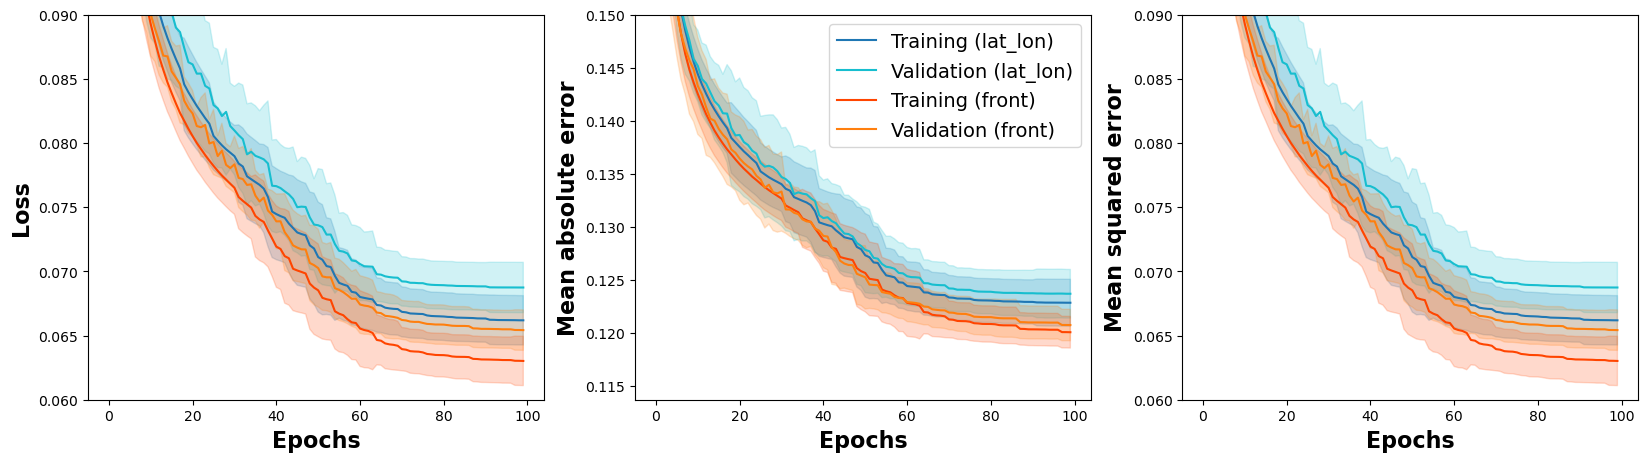

In [11]:
fig, ax = plt.subplots(1,3, figsize = (20,5))
requested_parameters = ('loss', 'mae', 'mse')
labels = ('Loss', 'Mean absolute error', 'Mean squared error')
ylims = ((0.06,0.09), (None, 0.15), (0.06,0.09))
std_f = 1
fontsize = 16
for i in range(len(requested_parameters)):
    requested_param = requested_parameters[i]
    rp_val = 'val_' + requested_param
    rp_mean = requested_param + '_mean'
    rp_std = requested_param + '_std'
    rp_val_mean = 'val_' + requested_param + '_mean'
    rp_val_std = 'val_' + requested_param + '_std'
    df = df_lat_lon
    ax[i].plot(df[rp_mean], label = 'Training (lat_lon)', color = 'C0')
    ax[i].fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'C0')
    ax[i].plot(df[rp_val_mean], label = 'Validation (lat_lon)', color = 'C9')
    ax[i].fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C9')

    df = df_front
    ax[i].plot(df[rp_mean], label = 'Training (front)', color = 'orangered')
    ax[i].fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2, color = 'orangered')
    ax[i].plot(df[rp_val_mean], label = 'Validation (front)', color = 'C1')
    ax[i].fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2, color = 'C1')


    #ax[i].plot(df[rp_mean], label = 'Training')
    #ax[i].fill_between(df.index, df[rp_mean]+ std_f * df[rp_std], df[rp_mean]- std_f * df[rp_std], alpha = 0.2)
    #ax[i].plot(df[rp_val_mean], label = 'Validation')
    #ax[i].fill_between(df.index, df[rp_val_mean]+ std_f * df[rp_val_std], df[rp_val_mean]- std_f * df[rp_val_std], alpha = 0.2)
    fontsize = 16
    ax[i].set_xlabel('Epochs', fontsize = fontsize, weight = 'bold')
    ax[i].set_ylabel(labels[i], fontsize = fontsize, weight = 'bold')
    ax[i].set_ylim(ylims[i])
ax[1].legend(fontsize = fontsize-2, markerscale = 2)
    

### **Apply a trained nn to the test data set**

Create functions to:
- Load in the test data
- Load in the neural network model
- Load in the normalisation metrics for the training/validation dataset used to train the model
- Apply the neural network model to the normalised test data

In [12]:
# Load in all the data
def load_test_data(this_collection, verbose = 0):
    df_total = pd.read_csv(fp_all_data)
    print('\033[1m' + 'You have loaded data to apply the nn to:' + '\033[0m')
    print(fp_all_data)
    
    months_mask, years_mask = define_params.month_year_by_collection(this_collection, title = False)
    months_mask_all, years_mask_all = define_params.month_year_by_collection('whole_dataset', title = False)
    
    if np.sum(~np.isin(df_total.month, months_mask)) != 0 & np.sum(~np.isin(df_total.year, years_mask)) != 0:
        print('Some months and some years were left out for testing and I don\'t know how to deal with this')
        print('Please help')
    elif np.sum(~np.isin(df_total.month, months_mask)) != 0:
        df_sel = df_total[~np.isin(df_total.month, months_mask)]
        if verbose == 1:
            print('\033[1m' + 'You have selected part of this dataset:' + '\033[0m')
            print('Selected by month')
    elif np.sum(~np.isin(df_total.year, years_mask)) != 0:
        df_sel = df_total[~np.isin(df_total.year, years_mask)]
        if verbose > 0:
            print('\033[1m' + 'You have selected part of this dataset:' + '\033[0m')
            print('Selected by year: ' + this_collection)
    # Convert imported data to xarray
    clean_df = df_sel.to_xarray()
    return clean_df

In [13]:
# Set the model filepath and load the normalisation metrics 
def load_model_nn(exp_name, this_collection, seed_nb, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
    fp_model = path_model + 'model_nn_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                    + str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.keras'
    model = keras.models.load_model(fp_model)
    if verbose == 1:
        print('\033[1m' + 'You have loaded a trained neural network:' + '\033[0m')
        print(fp_model)
    return model
    
def load_normalisation_metrics(this_collection, norm_method = 'std', verbose = 0):
    fp_norm_metrics = path_norm_metrics + this_collection + '_metrics_norm.nc'
    norm_metrics_file = xr.open_dataset(fp_norm_metrics)
    if verbose > 0:
        print('\033[1m' + 'You have loaded normalisation metrics:' + '\033[0m')
        print(fp_norm_metrics)
    norm_metrics = norm_metrics_file.sel(norm_method=norm_method).drop('norm_method').to_dataframe()
    return norm_metrics

In [14]:
def apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0):
    # First normalise input data 
    val_norm = pp.normalise_vars(clean_df,
                            norm_metrics.loc['mean_vars'],
                            norm_metrics.loc['range_vars'])
    # Import the desired variables, and create a list 
    var_list = define_params.var_list_by_exp_name(exp_name)
    input_vars = list(np.array(var_list)[~(np.array(var_list) == 'melt_m_ice_per_y')])
    # Split into input and reference datasets
    x_val_norm = val_norm[input_vars]
    y_val_norm = val_norm['melt_m_ice_per_y']
    # Apply the model 
    #shape = x_val_norm.to_array().values.shape[1], x_val_norm.to_array().values.shape[0]
    #y_out_norm = model.predict(x_val_norm.to_array().values.reshape(shape),verbose = 0)
    y_out_norm = model.predict(x_val_norm.to_array().values.T,verbose = 0)
    y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
    y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})    
    # denormalise the output
    y_out = pp.denormalise_vars(y_out_norm_xr, 
                             norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                             norm_metrics['melt_m_ice_per_y'].loc['range_vars'])
    if verbose > 0:
        print('\033[1m' + 'You have applied the neural network to the chosen data:' + '\033[0m')
    return y_out

In [15]:
def apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
    norm_metrics = load_normalisation_metrics(this_collection, verbose = verbose)
    clean_df = load_test_data(this_collection, verbose = verbose)
    seed_nb_array = np.arange(1,11,1)
    list_melt_seeds = []
    df_ref_pred = pd.DataFrame({'lat': clean_df.lat, 
                                'lon': clean_df.lon,
                                'basin': clean_df.basins_NEMO,
                                'area': clean_df.approx_area,
                                'year': clean_df.year, 
                                'month': clean_df.month, 
                                'melt_m_ice_per_y': clean_df.melt_m_ice_per_y})
    for i in range(len(seed_nb_array)):
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
        if verbose == 2:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 1) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 1)
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed', end = '\r')
        else:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 0) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0)
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed', end = '\r')
    # Calculate the ensemble mean 
    df_ref_pred['melt_pred_mean'] = np.mean(df_ref_pred[list_melt_seeds], axis = 1).values
    
    # If you want to make the files smaller, you can save the results with just the ensemble mean
    # by setting keep_all_runs to False 
    if keep_all_runs == False:
        df_ref_pred_save = df_ref_pred[list(df_ref_pred.columns.values[~np.isin(list(df_ref_pred.columns.values), list_melt_seeds)])]
        print('Warning, you have not saved the results of each nn, just the ensemble mean')
        sims = 'just_mean'
    else:
        df_ref_pred_save = df_ref_pred
        print('You have saved the results of each nn, and the ensemble mean')
        sims = 'all_sims'
    # Set the filepath and save the output
    fp_ref_pred = path_model + 'applied_nn' + '_' + mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                        + sims + '_' + TS_opt + '_' + norm_method + '.csv'
    df_ref_pred.to_csv(fp_ref_pred, index = False)
    if verbose > 0:
        print('\033[1m' + 'You have saved the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)

**Apply the neural network to the test data (aka data not used for training)**

In [18]:
this_collection = 'no_middle_5'
exp_name = 'slope_front'
keep_all_runs = True

apply_nn = True
if apply_nn == True:
    apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 1)
else:
    print('No neural network applied, change apply_nn to True if desired')

You have loaded normalisation metrics:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/no_middle_5_metrics_norm.nc
You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv
You have selected part of this dataset:
Selected by year: no_middle_5
You have saved the results of each nn, and the ensemble mean
You have saved the results of applying the neural network to the test dataset:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/applied_nn_small_slope_front_no_middle_5_all_sims_extrap_std.csv


In [23]:
this_collection = 'no_jun_dec'
exp_name = 'slope_front'
keep_all_runs = True

apply_nn = True
if apply_nn == True:
    apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 1)
else:
    print('No neural network applied, change apply_nn to True if desired')

You have loaded normalisation metrics:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/no_jun_dec_metrics_norm.nc
You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv
You have selected part of this dataset:
Selected by month
You have saved the results of each nn, and the ensemble mean
You have saved the results of applying the neural network to the test dataset:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/applied_nn_small_slope_front_no_jun_dec_all_sims_extrap_std.csv


In [22]:
this_collection = 'no_mar_oct'
exp_name = 'slope_front'
keep_all_runs = True

apply_nn = True
if apply_nn == True:
    apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 1)
else:
    print('No neural network applied, change apply_nn to True if desired')

You have loaded normalisation metrics:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/no_mar_oct_metrics_norm.nc
You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv
You have selected part of this dataset:
Selected by month
You have saved the results of each nn, and the ensemble mean
You have saved the results of applying the neural network to the test dataset:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/applied_nn_small_slope_front_no_mar_oct_all_sims_extrap_std.csv


In [ ]:
purple

### **Start here if you want to look at results which have already been processed**

In [16]:
def load_results_nn(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0):
    if keep_all_runs == False:
        sims = 'just_mean'
    else:
        sims = 'all_sims'
    fp_ref_pred = path_model + 'applied_nn' + '_' + mod_size + '_' +exp_name + '_' + this_collection + '_' \
                                        + sims + '_' + TS_opt + '_' + norm_method + '.csv'
    df_ref_pred = pd.read_csv(fp_ref_pred)
    if verbose == 1:
        print('\033[1m' + 'You have loaded the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)
    return df_ref_pred

from sklearn.linear_model import LinearRegression as regres
# Linear regression model creation and fitting
def regression_analysis(ref_melt, pred_melt):
    ref_melt = ref_melt.values.reshape(-1,1)
    pred_melt = pred_melt.values.reshape(-1,1)
    model = regres()
    reg = model.fit(ref_melt, pred_melt)
    slope = reg.coef_[0][0] 
    intercept = reg.intercept_[0]
    rsq = reg.score(ref_melt, pred_melt)
    return slope, intercept, rsq

In [17]:
# To import the results for 
#this_collection = 'up_to_2018'
#exp_name = 'slope_front'
#ref_pred = load_results_nn(this_collection, exp_name)
#slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])

**Looking at just the overall scatter regression product**

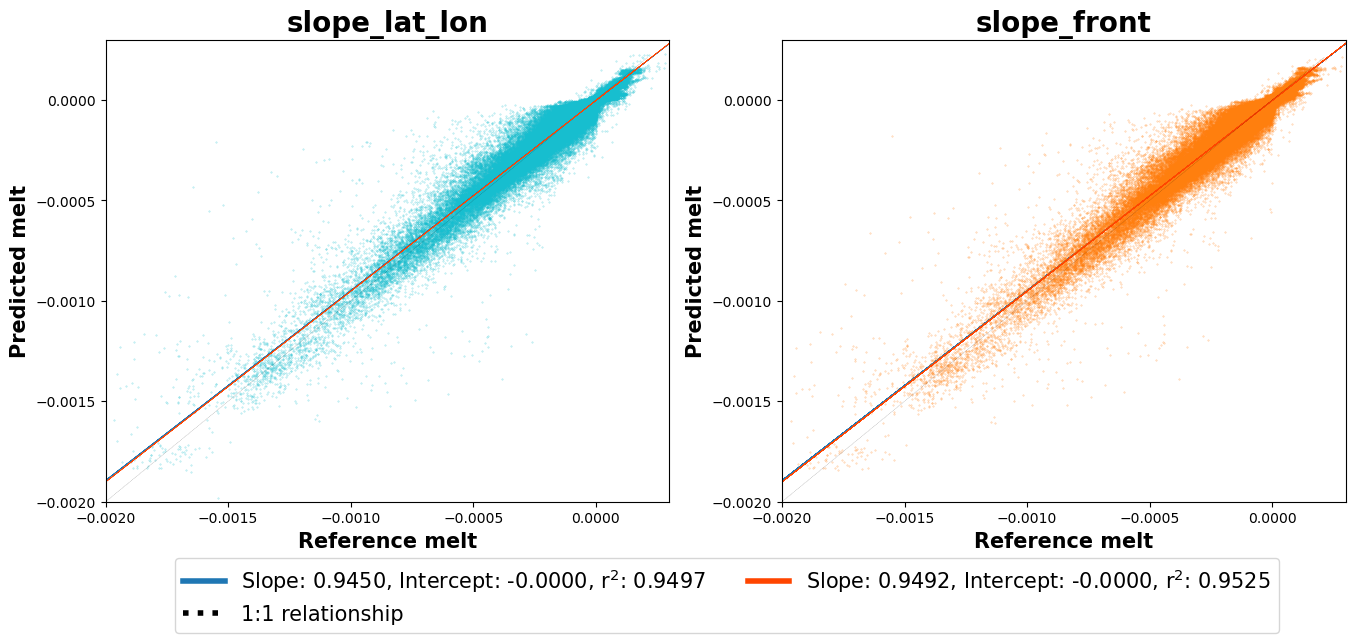

In [18]:
fig, ax = plt.subplots(1,2, figsize = (16,6))
def plot_scatter_label(this_collection, exp_name, ax_all, ax, colors):
    ref_pred = load_results_nn(this_collection, exp_name, verbose = 0)
    slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])
    ax.scatter(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'], s = 0.1, color = colors[0], \
          alpha = 0.5)
    for j in range(2):
        ax_all[j].plot(ref_pred['melt_m_ice_per_y'], ref_pred['melt_m_ice_per_y'] * slope + intercept, \
                zorder = 1, color = colors[1], linewidth = 0.4, \
        label = 'Slope: {:.4f}, Intercept: {:.4f}, r$^2$: {:.4f}'.format(slope, intercept, rsq))
    ax.set_xlabel('Reference melt', fontweight = 'bold', fontsize = 15)
    ax.set_ylabel('Predicted melt', fontweight = 'bold', fontsize = 15)
    x_ample = np.arange(np.min(ref_pred['melt_m_ice_per_y']),np.max(ref_pred['melt_m_ice_per_y']),0.0005)
    ax.plot(x_ample, x_ample, zorder = 1, color = 'black', linewidth = 0.2, label = '1:1 relationship', linestyle = 'dotted')
    ax.set_xlim(-0.002,0.0003)
    ax.set_ylim(-0.002,0.0003)
    ax.set_title(exp_name, fontweight = 'bold', fontsize = 20)
#titles = [']
plot_scatter_label('no_middle_5', 'slope_lat_lon', ax, ax[0], colors = ('C9', 'C0'))
plot_scatter_label('no_middle_5', 'slope_front', ax, ax[1], colors = ('C1', 'orangered'))

def flip(items, ncol):
    import itertools
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])
handles, labels = ax[1].get_legend_handles_labels()
leg = ax[1].legend(flip(handles, 2), flip(labels, 2), ncol=2, markerscale = 20, bbox_to_anchor=[0.9, -0.1], \
                   loc = 'upper right', fontsize = 15)
# set the linewidth of each legend object
for legobj in leg.legend_handles:
    legobj.set_linewidth(4.0)

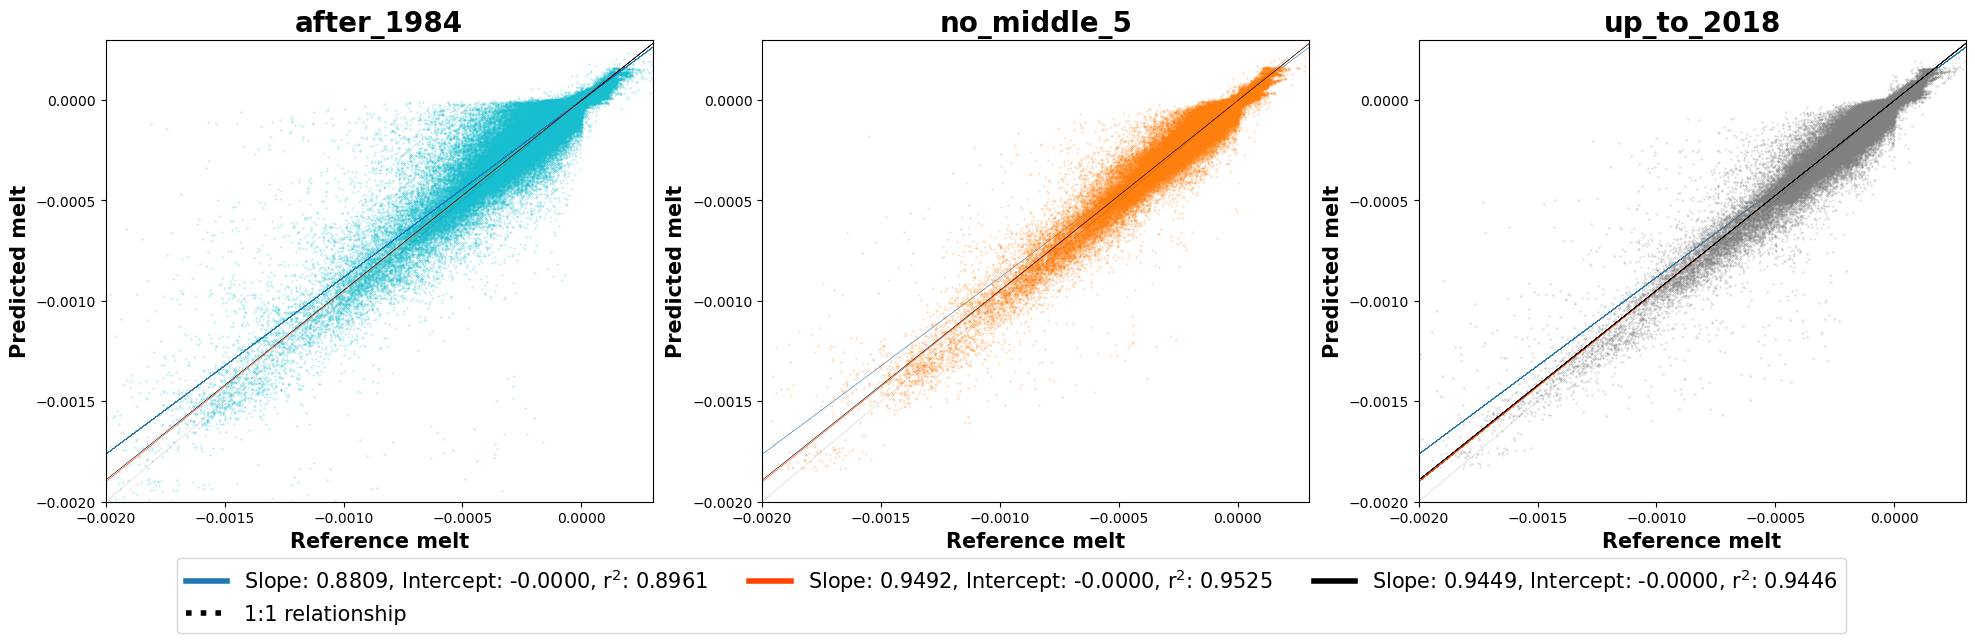

In [19]:
fig, ax = plt.subplots(1,3, figsize = (24,6))
def plot_scatter_label(this_collection, exp_name, ax_all, ax, colors):
    ref_pred = load_results_nn(this_collection, exp_name, verbose = 0)
    slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])
    ax.scatter(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'], s = 0.1, color = colors[0], \
          alpha = 0.5)
    for j in range(3):
        ax_all[j].plot(ref_pred['melt_m_ice_per_y'], ref_pred['melt_m_ice_per_y'] * slope + intercept, \
        zorder = 1, color = colors[1], linewidth = 0.2, \
        label = 'Slope: {:.4f}, Intercept: {:.4f}, r$^2$: {:.4f}'.format(slope, intercept, rsq))
    ax.set_xlabel('Reference melt', fontweight = 'bold', fontsize = 15)
    ax.set_ylabel('Predicted melt', fontweight = 'bold', fontsize = 15)
    x_ample = np.arange(np.min(ref_pred['melt_m_ice_per_y']),np.max(ref_pred['melt_m_ice_per_y']),0.0005)
    ax.plot(x_ample, x_ample, zorder = 1, color = 'black', linewidth = 0.2, label = '1:1 relationship', linestyle = 'dotted')
    ax.set_xlim(-0.002,0.0003)
    ax.set_ylim(-0.002,0.0003)
    ax.set_title(this_collection, fontweight = 'bold', fontsize = 20)
#titles = [']
exp_name = 'slope_front'
plot_scatter_label('after_1984', exp_name, ax, ax[0], colors = ('C9', 'C0'))
plot_scatter_label('no_middle_5', exp_name, ax, ax[1], colors = ('C1', 'orangered'))
plot_scatter_label('up_to_2018', exp_name, ax, ax[2], colors = ('grey', 'black'))

#leg = ax[2].legend(markerscale = 20, bbox_to_anchor=[1.02, -0.1], loc = 'upper right', fontsize = 15, ncol = 4)
## set the linewidth of each legend object
#for legobj in leg.legend_handles:
#    legobj.set_linewidth(4.0)

def flip(items, ncol):
    import itertools
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])
handles, labels = ax[1].get_legend_handles_labels()
leg = ax[2].legend(flip(handles, 2), flip(labels, 2), ncol=3, markerscale = 20, bbox_to_anchor=[0.8, -0.1], \
                   loc = 'upper right', fontsize = 15)
# set the linewidth of each legend object
for legobj in leg.legend_handles:
    legobj.set_linewidth(4.0)

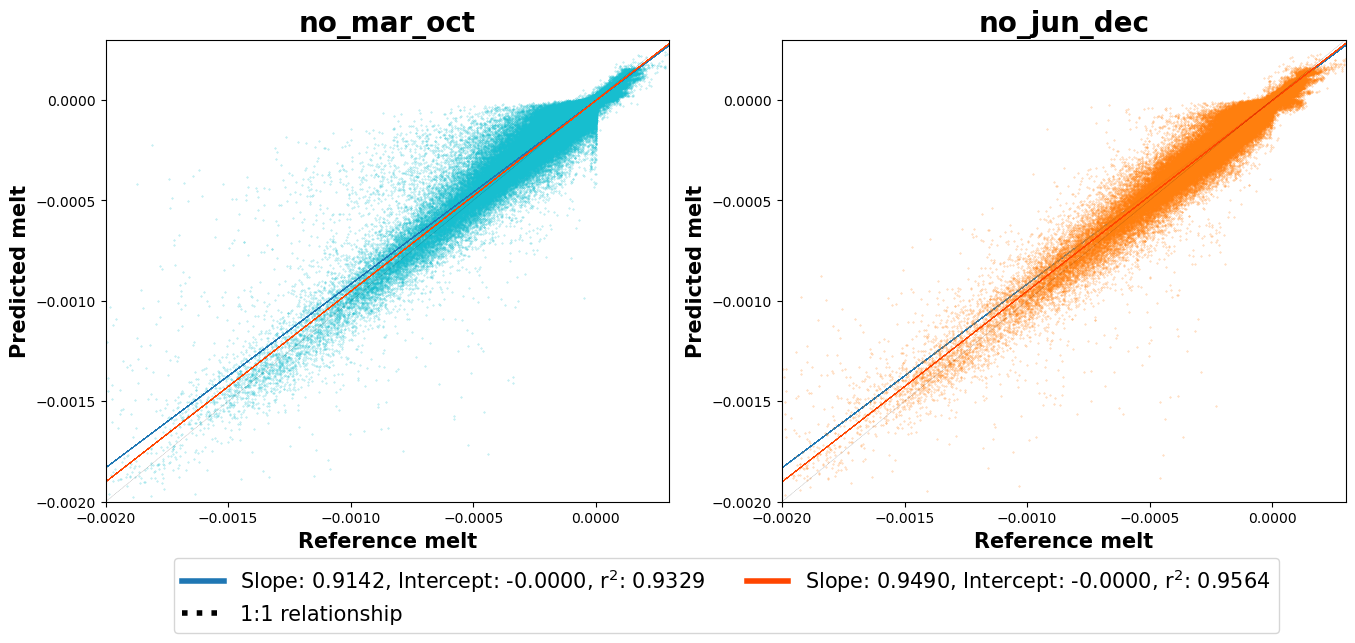

In [20]:
fig, ax = plt.subplots(1,2, figsize = (16,6))
def plot_scatter_label(this_collection, exp_name, ax_all, ax, colors):
    ref_pred = load_results_nn(this_collection, exp_name, verbose = 0)
    slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])
    ax.scatter(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'], s = 0.1, color = colors[0], \
          alpha = 0.5)
    for j in range(2):
        ax_all[j].plot(ref_pred['melt_m_ice_per_y'], ref_pred['melt_m_ice_per_y'] * slope + intercept, \
                zorder = 1, color = colors[1], linewidth = 0.4, \
        label = 'Slope: {:.4f}, Intercept: {:.4f}, r$^2$: {:.4f}'.format(slope, intercept, rsq))
    ax.set_xlabel('Reference melt', fontweight = 'bold', fontsize = 15)
    ax.set_ylabel('Predicted melt', fontweight = 'bold', fontsize = 15)
    x_ample = np.arange(np.min(ref_pred['melt_m_ice_per_y']),np.max(ref_pred['melt_m_ice_per_y']),0.0005)
    ax.plot(x_ample, x_ample, zorder = 1, color = 'black', linewidth = 0.2, label = '1:1 relationship', linestyle = 'dotted')
    ax.set_xlim(-0.002,0.0003)
    ax.set_ylim(-0.002,0.0003)
    ax.set_title(this_collection, fontweight = 'bold', fontsize = 20)
#titles = [']
plot_scatter_label('no_mar_oct', 'slope_front', ax, ax[0], colors = ('C9', 'C0'))
plot_scatter_label('no_jun_dec', 'slope_front', ax, ax[1], colors = ('C1', 'orangered'))

def flip(items, ncol):
    import itertools
    return itertools.chain(*[items[i::ncol] for i in range(ncol)])
handles, labels = ax[1].get_legend_handles_labels()
leg = ax[1].legend(flip(handles, 2), flip(labels, 2), ncol=2, markerscale = 20, bbox_to_anchor=[0.9, -0.1], \
                   loc = 'upper right', fontsize = 15)
# set the linewidth of each legend object
for legobj in leg.legend_handles:
    legobj.set_linewidth(4.0)

In [21]:
# To import the results for 
this_collection = 'up_to_2018'
exp_name = 'slope_front'
ref_pred = load_results_nn(this_collection, exp_name)
density_ice = 917 # kg/m3
ref_pred.loc[:,'melt_Gt_per_yr'] = ((ref_pred.loc[:,'melt_m_ice_per_y'] * ref_pred.loc[:,'area']) * density_ice/1e12)
ref_pred.loc[:,'melt_pred_Gt'] = ((ref_pred.loc[:,'melt_pred_mean'] * ref_pred.loc[:,'area']) * density_ice/1e12)
#slope, intercept, rsq = regression_analysis(ref_pred['melt_m_ice_per_y'], ref_pred['melt_pred_mean'])

In [22]:
ref_pred

,lat,lon,basin,area,year,month,melt_m_ice_per_y,melt_01,melt_02,melt_03,melt_04,melt_05,melt_06,melt_07,melt_08,melt_09,melt_10,melt_pred_mean,melt_Gt_per_yr,melt_pred_Gt
0,-85.396736,-152.77846,59.0,1.630388e+07,2019,1,-2.113211e-06,1.805471e-06,-0.000002,-0.000004,-0.000003,-1.481432e-06,-0.000005,1.841956e-06,2.893707e-06,2.410947e-06,0.000005,-1.362216e-07,-3.159391e-08,-2.036602e-09
1,-85.368385,-154.12903,59.0,1.641368e+07,2019,1,3.458704e-07,-5.658283e-06,-0.000004,0.000008,-0.000016,-6.551636e-08,-0.000006,4.734054e-06,3.316487e-06,1.535271e-06,-0.000001,-1.542597e-06,5.205815e-09,-2.321815e-08
2,-85.365005,-153.69621,59.0,1.639403e+07,2019,1,-4.800135e-06,-7.094313e-07,-0.000003,-0.000005,-0.000010,-8.041207e-07,-0.000003,7.936542e-07,3.784298e-07,7.461494e-08,-0.000007,-2.763112e-06,-7.216199e-08,-4.153875e-08
3,-85.361430,-153.26420,59.0,1.637476e+07,2019,1,-4.705503e-06,-1.393739e-06,-0.000005,-0.000006,-0.000014,-1.409659e-06,-0.000005,2.510937e-06,-2.903260e-06,-3.586210e-07,-0.000003,-3.583245e-06,-7.065621e-08,-5.380478e-08
4,-85.357635,-152.83304,59.0,1.635611e+07,2019,1,-1.241118e-06,-8.551433e-08,-0.000005,-0.000001,-0.000007,-2.023375e-06,-0.000005,4.571662e-06,-5.138037e-06,-1.316592e-06,0.000002,-1.968438e-06,-1.861497e-08,-2.952371e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680095,-65.078710,97.00000,26.0,1.437647e+08,2023,12,-7.151923e-06,-1.776737e-05,-0.000028,-0.000018,-0.000026,-2.791740e-05,-0.000013,-1.643985e-05,-1.947544e-05,-1.817300e-05,-0.000025,-2.110665e-05,-9.428538e-07,-2.782536e-06
680096,-65.078710,-60.75000,113.0,1.437647e+08,2023,12,-1.396480e-05,-1.204091e-05,-0.000015,-0.000017,-0.000011,-1.788676e-05,-0.000017,-2.345436e-05,-1.983801e-05,-1.842149e-05,-0.000017,-1.685555e-05,-1.841011e-06,-2.222104e-06
680097,-65.078710,-60.50000,113.0,1.437647e+08,2023,12,-1.295732e-05,-2.626208e-05,-0.000017,-0.000022,-0.000029,-2.239539e-05,-0.000026,-2.140125e-05,-1.788600e-05,-2.318943e-05,-0.000025,-2.296542e-05,-1.708192e-06,-3.027582e-06
680098,-64.973160,-60.75000,113.0,1.450143e+08,2023,12,-3.712270e-05,-4.442542e-05,-0.000029,-0.000037,-0.000013,-2.069700e-05,-0.000029,-3.285689e-05,-2.912895e-05,-2.180949e-05,-0.000012,-2.685126e-05,-4.936506e-06,-3.570629e-06


In [23]:
basins = np.unique(ref_pred.basin)

Text(0.5, 0, 'Time')

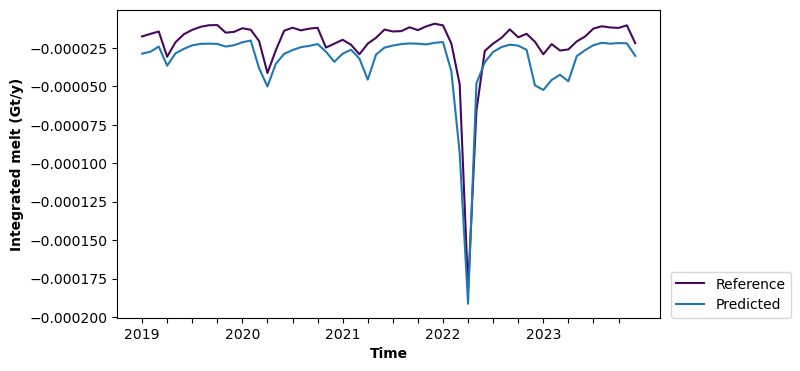

In [24]:
i = 3
fig, ax = plt.subplots(1,1, figsize = (7,4))
#for i in range(len(basins)):
basin = basins[i]
ref_basin = ref_pred[ref_pred.basin == basin]
ref_ym = ref_basin.groupby(['year', 'month']).sum()
plt.plot(ref_ym.melt_Gt_per_yr.values, c = plt.cm.viridis(i/len(basins)), label = 'Reference')
plt.plot(ref_ym.melt_pred_Gt.values, c = 'C0', label = 'Predicted')
plt.legend(loc = (1.02,0))
ticks = np.arange(0,60,3)
ax.set_xticks(ticks)
ax.set_xticklabels(('2019', '', '','', '2020', '', '','', '2021', '', '','', '2022', '', '','', '2023', '', '',''));
ax.set_ylabel('Integrated melt (Gt/y)', fontweight = 'bold')
ax.set_xlabel('Time', fontweight = 'bold')

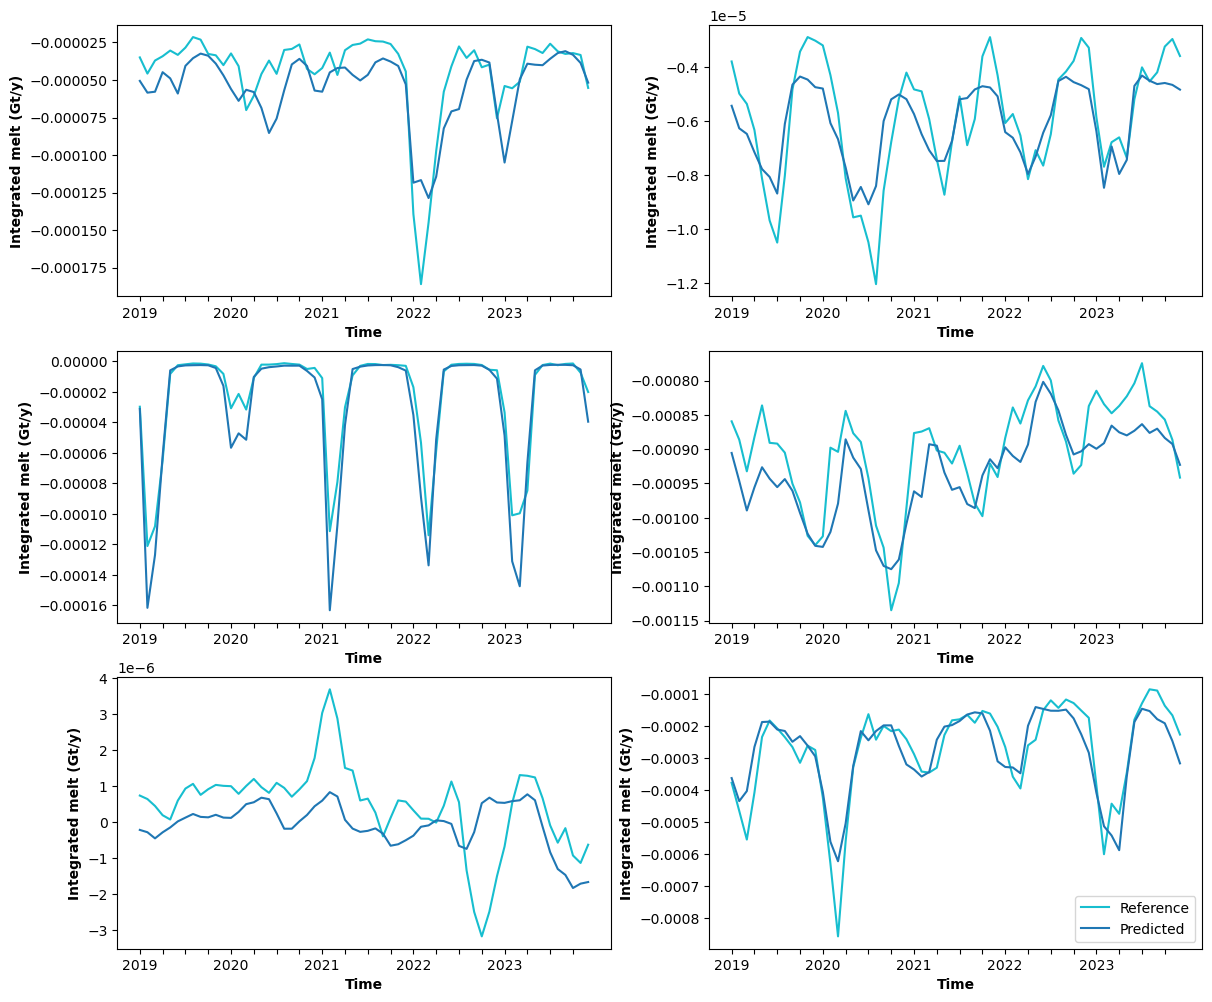

In [25]:
i = 3
fig, ax_all = plt.subplots(3,2, figsize = (14,12))
for i in (0,20,40,60,80,100):
    i = i + 9
    ii = np.mod(int(i/20), 3)
    jj = int((int(i/20) - np.mod(int(i/20),3))/3)
    ax = ax_all[ii,jj]
    #for i in range(len(basins)):
    basin = basins[i]
    ref_basin = ref_pred[ref_pred.basin == basin]
    ref_ym = ref_basin.groupby(['year', 'month']).sum()
    ax.plot(ref_ym.melt_Gt_per_yr.values, c = 'C9', label = 'Reference')
    ax.plot(ref_ym.melt_pred_Gt.values, c = 'C0', label = 'Predicted')
    ticks = np.arange(0,60,3)
    ax.set_xticks(ticks)
    ax.set_xticklabels(('2019', '', '','', '2020', '', '','', '2021', '', '','', '2022', '', '','', '2023', '', '',''));
    ax.set_ylabel('Integrated melt (Gt/y)', fontweight = 'bold')
    ax.set_xlabel('Time', fontweight = 'bold')
ax.legend(loc = 0)
    

In [26]:
years = np.unique(ref_pred.year)
months = np.unique(ref_pred.month)

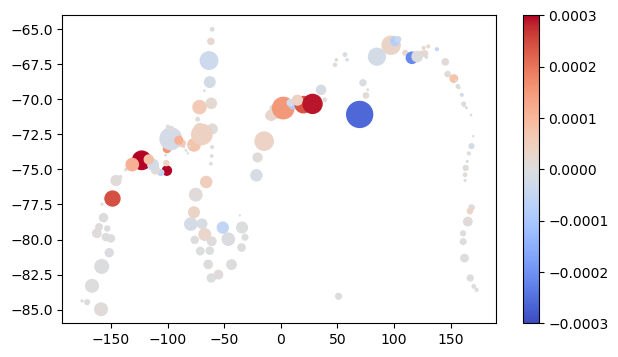

In [27]:
i = 3
j = 0
year = years[i]
month = months[j]
ref_ym = ref_pred[(ref_pred.year == year) & (ref_pred.month == month)]
ref_basin = ref_ym[['melt_pred_Gt', 'basin', 'melt_Gt_per_yr', 'area']].groupby('basin').sum()
ref_basin2 = ref_ym[['lat','lon', 'basin']].groupby('basin').mean()

fig, ax = plt.subplots(1,1, figsize = (7,4))
im = ax.scatter(ref_basin2.lon, ref_basin2.lat, s = ref_basin.area/100000000, c = ref_basin.melt_Gt_per_yr - ref_basin.melt_pred_Gt, cmap = 'coolwarm')
plt.colorbar(im, ax = ax)
#plt.clim(-0.006,0.006)
im.set_clim(-0.0003,0.0003)

In [28]:
import cartopy.crs as ccrs
# For plotting things on the polar stereographic grid with lat and lon coordinates 
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()
# Remember to add transform=trans

In [29]:
months_names = ('Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec')

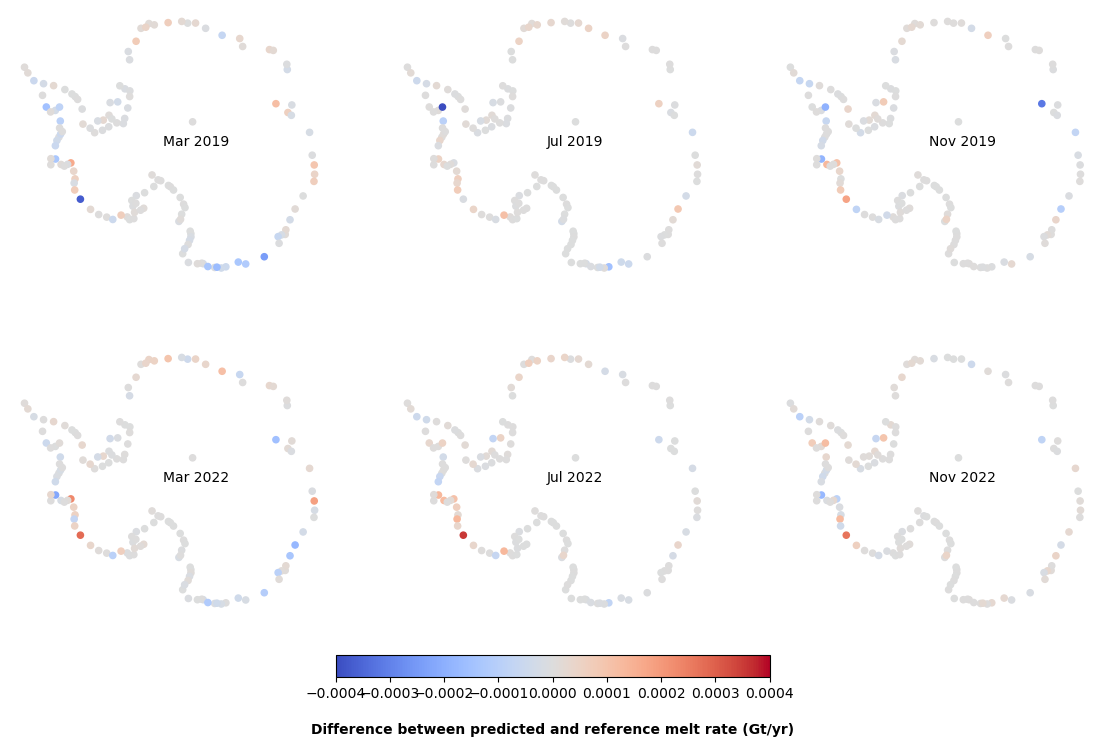

In [30]:
#fig, ax = plt.subplots(1,1, figsize = (7,5), subplot_kw={'projection': proj})
fig, ax_all = plt.subplots(2,3,figsize = (14,10), subplot_kw={'projection': proj})
for i in (0,3):
    for j in (0,4,8):
        ax = ax_all[int(i/2),int(j/4)]
        year = years[i]
        month = months[j+2]
        month_name = months_names[month-1]
        ref_ym = ref_pred[(ref_pred.year == year) & (ref_pred.month == month)]
        ref_basin = ref_ym[['melt_pred_Gt', 'basin', 'melt_Gt_per_yr', 'area']].groupby('basin').sum()
        ref_basin2 = ref_ym[['lat','lon', 'basin']].groupby('basin').mean()
        
        #im = ax.scatter(ref_basin2.lon, ref_basin2.lat, s = ref_basin.area/100000000, \
        #                c = ref_basin.melt_Gt_per_yr, \
        #                cmap = 'viridis', transform = trans)
        im = ax.scatter(ref_basin2.lon, ref_basin2.lat, s = 20, \
                        c = (ref_basin.melt_Gt_per_yr - ref_basin.melt_pred_Gt), \
                        cmap = 'coolwarm', transform = trans)
        #plt.colorbar(im, ax = ax)
        ax.annotate('{} {}'.format(month_name, year), xy = (0,0), xytext = (0,0))
        im.set_clim(-0.0004,0.0004)
        #im.set_clim(-0.004,0.001)
        ax.axis('off')
cbar = plt.colorbar(im, ax = ax_all, shrink = 0.4, orientation = 'horizontal', pad = 0.05)
cbar.set_label('\nDifference between predicted and reference melt rate (Gt/yr)', fontweight = 'bold')

In [49]:
for i in range(4):
    print(i, np.mod(i,2), int((i - np.mod(i,2))/2))

0 0 0
1 1 0
2 0 1
3 1 1


You have loaded:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nico_on_nemo_OPM026.nc


In [98]:
basins_NEMO

array([[ 9.,  9.,  9., ...,  9.,  9.,  9.],
       [ 9.,  9.,  9., ...,  9.,  9.,  9.],
       [ 9.,  9.,  9., ...,  9.,  9.,  9.],
       ...,
       [22., 22., 22., ..., 22., 22., 22.],
       [22., 22., 22., ..., 22., 22., 22.],
       [22., 22., 22., ..., 22., 22., 22.]])

In [108]:
from osgeo import gdal

ModuleNotFoundError: No module named 'osgeo'

ModuleNotFoundError: No module named 'rasterio'

In [101]:
plt.contour(

,lat,lon,basins
0,-85.396736,-152.778458,59.0
1,-85.368385,-154.129028,59.0
2,-85.365005,-153.696213,59.0
3,-85.361427,-153.264206,59.0
4,-85.357635,-152.833038,59.0
...,...,...,...
11345,-65.078712,97.000000,26.0
11346,-65.078712,-60.750000,113.0
11347,-65.078712,-60.500000,113.0
11348,-64.973160,-60.750000,113.0


In [89]:
dsREDCAV_NEMO

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

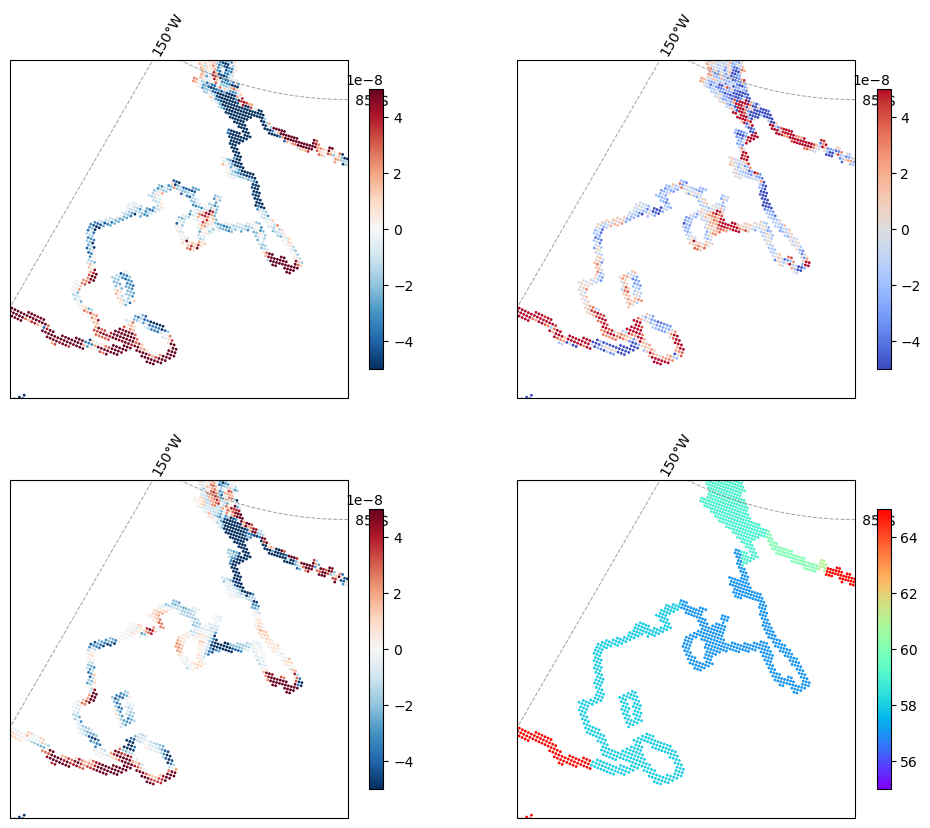

In [77]:
fig, axs_all = plt.subplots(2,2, figsize = (12,10), subplot_kw={'projection': proj} )
plts = ref_ym.melt_pred_Gt, ref_ym.melt_Gt_per_yr, ref_ym.melt_pred_Gt- ref_ym.melt_Gt_per_yr, ref_ym.basin
cmaps = ('RdBu_r', 'RdBu_r', 'coolwarm', 'rainbow')
for i in range(4):
    axs = axs_all[np.mod(i,2), int((i - np.mod(i,2))/2)]
    im = axs.scatter(ref_ym.lon, ref_ym.lat, c = (plts[i]), cmap = cmaps[i], transform = trans, s = 1)
    if i == 3:
        im.set_clim(55,65)
    else:
        im.set_clim(-0.00000005,0.00000005)
    plt.colorbar(im, ax = axs, shrink = 0.8)
    
    gl0 = axs.gridlines(draw_labels=True, linewidth=0.75, color='gray', alpha=0.7, linestyle='--',
                           dms=True, x_inline=False, y_inline=False )
    import matplotlib.ticker as mticker
    gl0.xlocator = mticker.FixedLocator(np.arange(-180,210,30))
    gl0.ylocator = mticker.FixedLocator(np.arange(-90,-50,5))
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    gl0.xformatter = LongitudeFormatter()
    gl0.yformatter = LatitudeFormatter()
    
    bounds = [-0.5e6,0e6,-1e6,-0.5e6]
    axs.set_xlim(bounds[0], bounds[1])
    axs.set_ylim(bounds[2], bounds[3])

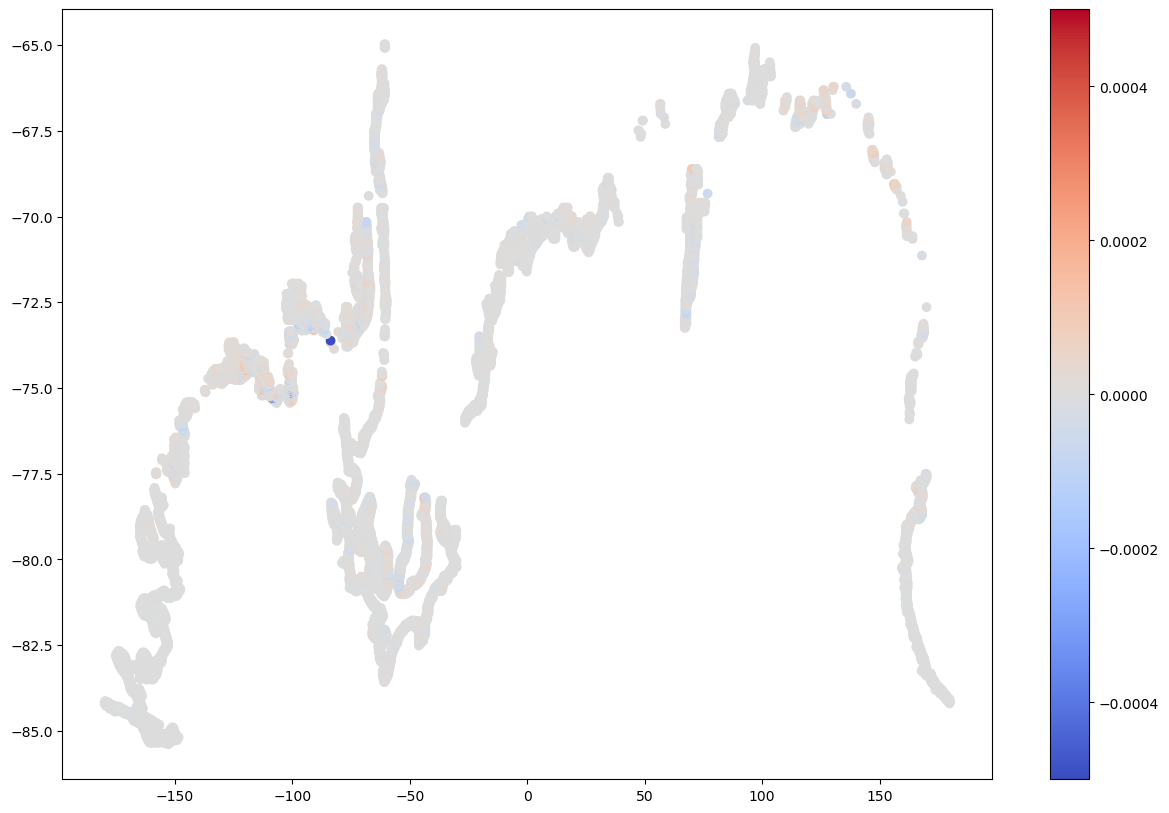

In [32]:
fig, ax = plt.subplots(1,1, figsize = (15,10))
im = plt.scatter(ref_ym.lon, ref_ym.lat, c = (ref_ym.melt_m_ice_per_y - ref_ym.melt_pred_mean), cmap = 'coolwarm')
plt.colorbar()
im.set_clim(-0.0005,0.0005)
#im.set_clim(-40000,40000)

In [33]:
ref_pred.melt_m_ice_per_y[mask_ym]

NameError: name 'mask_ym' is not defined

In [ ]:
purple

In [ ]:
plot_figure = False
if plot_figure == True:
    import matplotlib.gridspec as gridspec
    fig = plt.figure(figsize=(14, 12))
    gs = gridspec.GridSpec(8,2, width_ratios=[3, 1], height_ratios = [0.5,1.5,0.2,1.5,0.5,0.2, 1,1])
    
    ax = [[],[],[],[]]
    ax[0] = fig.add_subplot(gs[0:2, 0])
    ax[1] = fig.add_subplot(gs[3:5, 0])
    ax[2] = fig.add_subplot(gs[6:8,0])
    ax[3] = fig.add_subplot(gs[1:3, 1])
    
    
    im = [[],[],[]]
    im[0] = ax[0].scatter(clean_df.lon, clean_df.lat, c = clean_df.melt_m_ice_per_y, cmap = 'coolwarm', s = 0.1)
    im[1] = ax[1].scatter(clean_df.lon, clean_df.lat, c = y_out, cmap = 'coolwarm', s = 0.1)
    im[2] = ax[2].scatter(clean_df.lon, clean_df.lat, c = y_out - clean_df.melt_m_ice_per_y, cmap = 'coolwarm', s = 0.1)
    titles = ['Reference melt', 'Predicted melt', 'Difference']
    #im[1] = ax[1].scatter(clean_df.lon, clean_df.lat, c = y_out, cmap = 'coolwarm')
    for i in range(3):
        im[i].set_clim(-0.0002,0.0002)
        ax[i].set_title(titles[i], fontsize =20)
        #ax[i].set_xlim(-65,-50)
        #ax[i].set_ylim(-83.6,-81.1)
    plt.colorbar(im[0], ax = ax[0:2], orientation = 'vertical', shrink = 0.5, pad = 0.02)
    ax[1].annotate('Variables: {}\nYear:        {}\nMonth:     {}'.format(exp_name, year, month), \
                   xy = (0,-75), xytext = (1.05,0.05), fontsize = 10, textcoords='axes fraction', zorder = 10);
    im[2].set_clim(-0.0001,0.0001)
    cbar = plt.colorbar(im[2], ax = ax[2], orientation = 'vertical', shrink = 1, pad = 0.02)
    cbar.set_ticks((-0.0001,0,0.0001))    
    
    ax[3].scatter(clean_df.melt_m_ice_per_y, y_out, s = 1)
    ax[3].set_xlabel('Reference melt')
    ax[3].set_ylabel('Predicted melt')
    ax[3].set_xticks((-0.001, 0))
    x_ample = np.arange(-0.0018,0.0005,0.0005)
    ax[3].plot(x_ample, x_ample, zorder = 0, color = 'grey', linewidth = 0.2)

In [ ]:
y_out.to_netcdf(results_fp)
print('You saved:')
print(results_fp)